# Load the Dataset

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

df = pd.read_excel('data/TVET_Teachers.xlsx')

# Renaming columns to shorter, analysis-friendly names
df_cleaned = df.rename(columns={
    'Select your Educational Qualification.': 'Education',
    'Have you completed any training, certifications and/or workshops?': 'TrainingCompleted',
    'Select the training/certifications/workshops completed:': 'TrainingDetails',
    'Please select your Institution': 'Institution',
    "Do you apply Bloom's Taxonomy in your classroom?": 'BloomsTaxonomy',
    'Do you use Blended Learning?': 'BlendedLearning',
    'Select Department:': 'Department'
})

# Display the first few rows of the dataset with cleaned column names
df_cleaned.head()

,Education,TrainingCompleted,TrainingDetails,Institution,BloomsTaxonomy,BlendedLearning,Department
0,Master's,Yes,"Advanced pedagogy in TVET, Basic training course",Dhaka Govt. Polytechnic Institute,Yes,Yes,Non Technical
1,Bachelor's,Yes,Basic training course,Dhaka Govt. Polytechnic Institute,No,No,Chemical
2,Master's,No,NaN,Dhaka Govt. Polytechnic Institute,I Don't Know,Yes,Non Technical
3,Bachelor's,No,NaN,Dhaka Govt. Polytechnic Institute,No,No,Non Technical
4,Bachelor's,No,NaN,Dhaka Govt. Polytechnic Institute,I Don't Know,Yes,Chemical


## Fig 1. Distribution of Educational Qualification

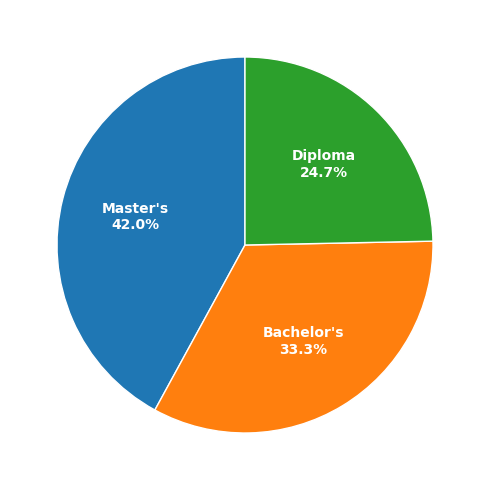

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get value counts for Education
education_counts = df_cleaned['Education'].value_counts()

# Plotting the styled pie chart
plt.figure(figsize=(5, 5))
wedges, texts, autotexts = plt.pie(
    education_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("tab10"),
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 10, 'weight': 'bold'}
)

# Formatting annotations inside slices
for i, autotext in enumerate(autotexts):
    # Get label and value for the current wedge
    label = education_counts.index[i]
    count = education_counts.iloc[i]
    # Set the text inside the slice
    autotext.set_text(f"{label}\n{autotext.get_text()}")

    # Optional: Customize annotation text size and color
    autotext.set_color('white')

# Adding title
# plt.title('Distribution of Educational Qualifications')
plt.tight_layout()
plt.show()


## Fig 2. Distribution of Trained and Non Trained Teachers

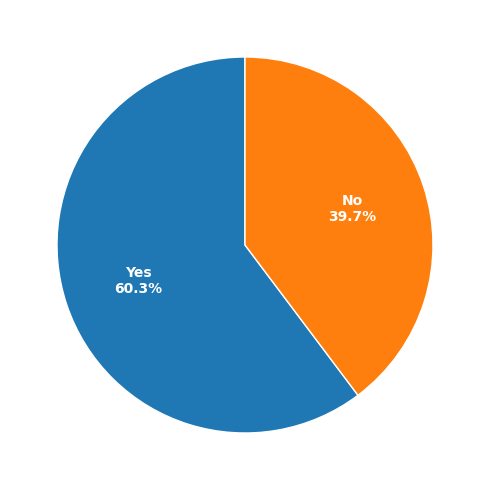

In [3]:
# Plot a pie chart for the 'TrainingCompleted' column
plt.figure(figsize=(5, 5))
training_counts = df_cleaned['TrainingCompleted'].value_counts()
wedges, texts, autotexts = plt.pie(
    training_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("tab10"),
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 10, 'weight': 'bold'}
)

# Formatting annotations inside slices
for i, autotext in enumerate(autotexts):
    label = training_counts.index[i]
    count = training_counts.iloc[i]
    autotext.set_text(f"{label}\n{autotext.get_text()}")
    autotext.set_color('white')

# Adding title
# plt.title('Distribution of Completed Trainings')

plt.tight_layout()
plt.show()

## Fig 3. Distribution of completed trainings

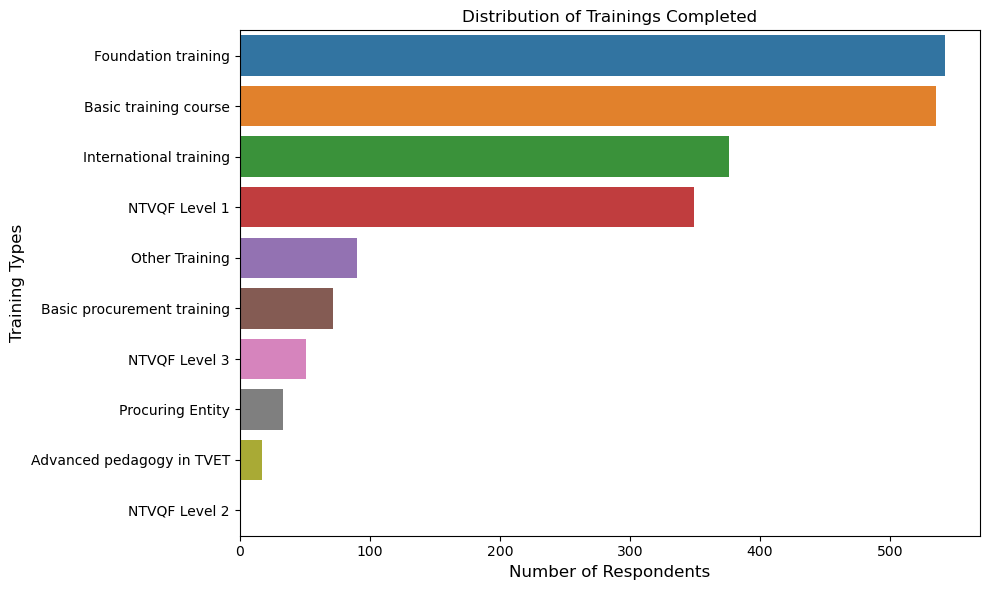

In [4]:
# Define the list of trainings
trainings = [
    'Advanced pedagogy in TVET',
    'Basic procurement training',
    'Basic training course',
    'Foundation training',
    'International training',
    'NTVQF Level 1',
    'NTVQF Level 2',
    'NTVQF Level 3',
    'Procuring Entity',
    'Other Training'
]

# Convert the trainings list to lowercase for comparison
trainings_lower = [training.lower() for training in trainings]

df = pd.read_excel('data/TVET_Teachers.xlsx')

# Renaming columns to shorter, analysis-friendly names
df_cleaned = df.rename(columns={
    'Select your Educational Qualification.': 'Education',
    'Have you completed any training, certifications and/or workshops?': 'TrainingCompleted',
    'Select the training/certifications/workshops completed:': 'TrainingDetails',
    'Please select your Institution': 'Institution',
    "Do you apply Bloom's Taxonomy in your classroom?": 'BloomsTaxonomy',
    'Do you use Blended Learning?': 'BlendedLearning',
    'Select Department:': 'Department'
})

# Initialize a dictionary to count occurrences of each training
training_counts = {training: 0 for training in trainings}

# Count occurrences of each training in the 'TrainingDetails' column
df_cleaned['TrainingDetails'] = df_cleaned['TrainingDetails'].fillna('')  # Replace NaN with empty string
for details in df_cleaned['TrainingDetails']:
    details_lower = details.lower()  # Convert the details to lowercase for case-insensitive matching
    for idx, training_lower in enumerate(trainings_lower):
        if training_lower in details_lower:
            training_counts[trainings[idx]] += 1

# Convert the counts to a sorted DataFrame for visualization
training_counts_df = pd.DataFrame(
    list(training_counts.items()), columns=['Training', 'Count']
).sort_values(by='Count', ascending=False)

# Plot the distribution of trainings completed
plt.figure(figsize=(10, 6))
sns.barplot(x=training_counts_df['Count'], y=training_counts_df['Training'], palette="tab10")
plt.title('Distribution of Trainings Completed')
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Training Types', fontsize=12)
plt.tight_layout()
plt.show()


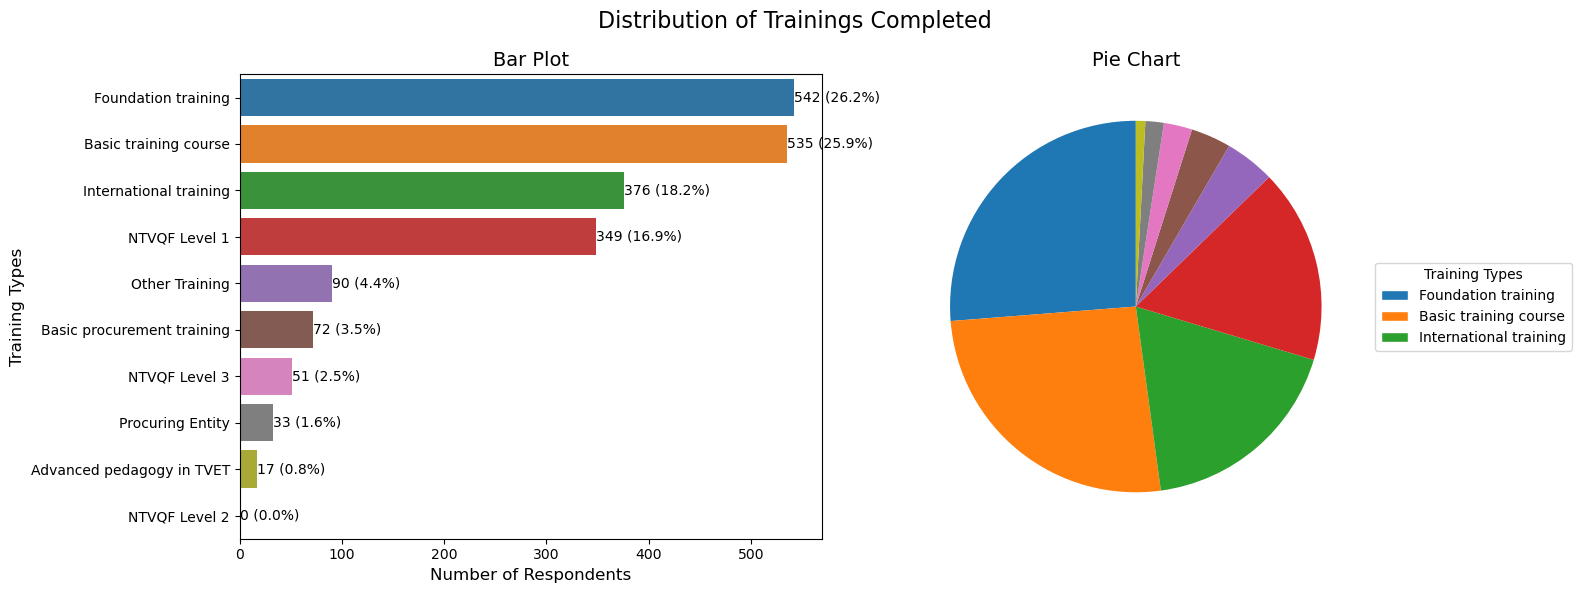

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the list of trainings
trainings = [
    'Advanced pedagogy in TVET',
    'Basic procurement training',
    'Basic training course',
    'Foundation training',
    'International training',
    'NTVQF Level 1',
    'NTVQF Level 2',
    'NTVQF Level 3',
    'Procuring Entity',
    'Other Training'
]

# Convert the trainings list to lowercase for comparison
trainings_lower = [training.lower() for training in trainings]

# Load the dataset
df = pd.read_excel('data/TVET_Teachers.xlsx')

# Renaming columns to shorter, analysis-friendly names
df_cleaned = df.rename(columns={
    'Select your Educational Qualification.': 'Education',
    'Have you completed any training, certifications and/or workshops?': 'TrainingCompleted',
    'Select the training/certifications/workshops completed:': 'TrainingDetails',
    'Please select your Institution': 'Institution',
    "Do you apply Bloom's Taxonomy in your classroom?": 'BloomsTaxonomy',
    'Do you use Blended Learning?': 'BlendedLearning',
    'Select Department:': 'Department'
})

# Initialize a dictionary to count occurrences of each training
training_counts = {training: 0 for training in trainings}

# Count occurrences of each training in the 'TrainingDetails' column
df_cleaned['TrainingDetails'] = df_cleaned['TrainingDetails'].fillna('')  # Replace NaN with empty string
for details in df_cleaned['TrainingDetails']:
    details_lower = details.lower()  # Convert the details to lowercase for case-insensitive matching
    for idx, training_lower in enumerate(trainings_lower):
        if training_lower in details_lower:
            training_counts[trainings[idx]] += 1

# Convert the counts to a sorted DataFrame for visualization
training_counts_df = pd.DataFrame(
    list(training_counts.items()), columns=['Training', 'Count']
).sort_values(by='Count', ascending=False)

# Create a 1x2 subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart
sns.barplot(x=training_counts_df['Count'], y=training_counts_df['Training'], palette="tab10", ax=axes[0])
axes[0].set_title('Bar Plot', fontsize=14)
axes[0].set_xlabel('Number of Respondents', fontsize=12)
axes[0].set_ylabel('Training Types', fontsize=12)

# Add percentage labels inside the bars
for index, value in enumerate(training_counts_df['Count']):
    percentage = f'{(value / training_counts_df["Count"].sum() * 100):.1f}%'
    axes[0].text(value, index, f'{value} ({percentage})', color='black', ha='left', va='center')

# Plot 2: Pie chart
axes[1].pie(
    training_counts_df['Count'], 
    # labels=training_counts_df['Training'], 
    # autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette("tab10"),
    textprops={'fontsize': 10}
)
axes[1].set_title('Pie Chart', fontsize=14)
axes[1].legend(wedges, training_counts_df['Training'], title="Training Types", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Adjust layout and display
plt.suptitle('Distribution of Trainings Completed', fontsize=16)
plt.tight_layout()
plt.show()


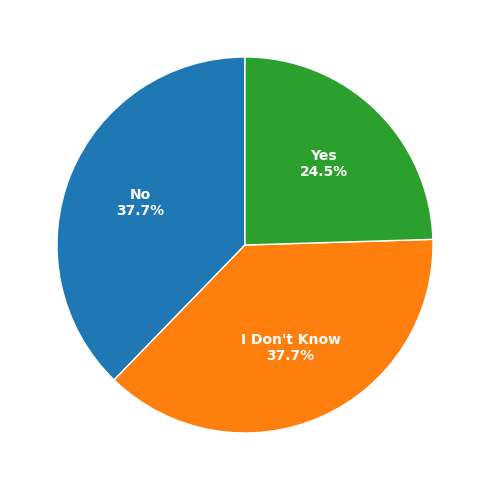

In [ ]:
# Generate a pie chart of people who apply Bloom's Taxonomy
plt.figure(figsize=(5, 5))
blooms_counts = df_cleaned['BloomsTaxonomy'].value_counts()
wedges, texts, autotexts = plt.pie(
    blooms_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("tab10"),
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 10, 'weight': 'bold'}
)

# Formatting annotations inside slices
for i, autotext in enumerate(autotexts):
    label = blooms_counts.index[i]
    count = blooms_counts.iloc[i]
    autotext.set_text(f"{label}\n{autotext.get_text()}")
    autotext.set_color('white')

# Adding title
# plt.title('Application of Bloom\'s Taxonomy')
plt.tight_layout()
plt.show()

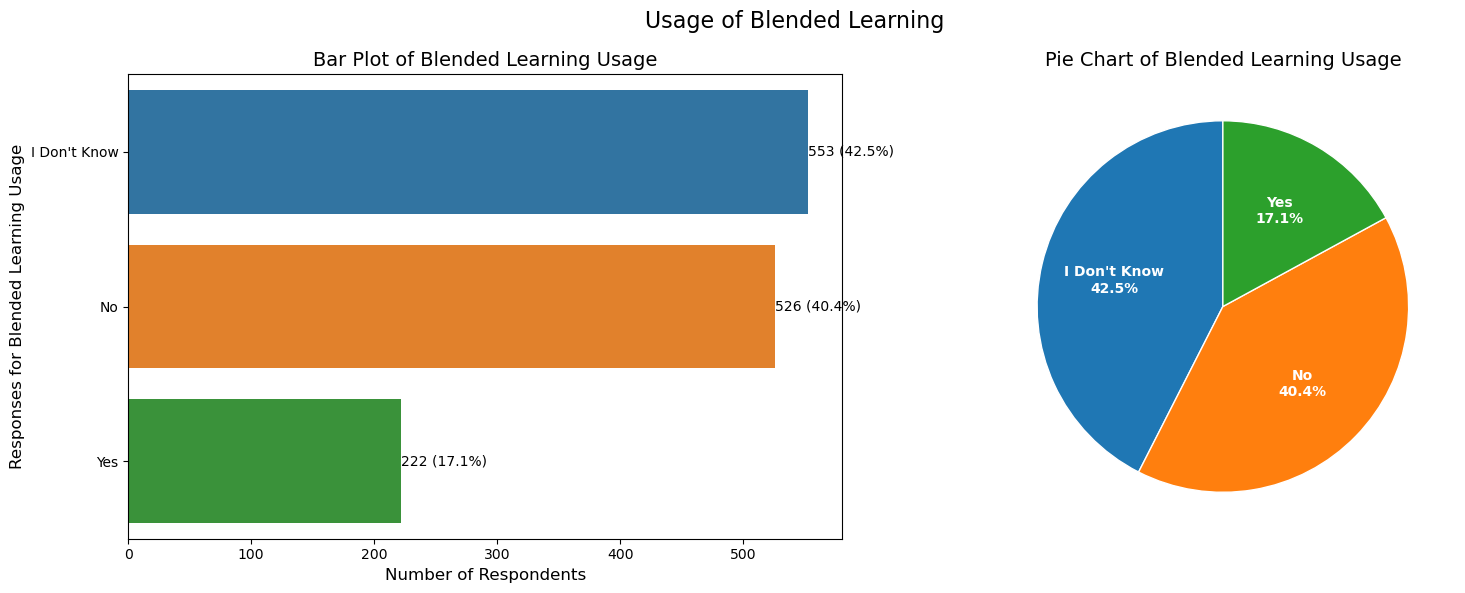

In [24]:
# Calculate value counts for BlendedLearning
blended_counts = df_cleaned['BlendedLearning'].value_counts()

# Create a 1x2 subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart
sns.barplot(x=blended_counts.values, y=blended_counts.index, palette="tab10", ax=axes[0])
axes[0].set_title('Bar Plot of Blended Learning Usage', fontsize=14)
axes[0].set_xlabel('Number of Respondents', fontsize=12)
axes[0].set_ylabel('Responses for Blended Learning Usage', fontsize=12)

# Add percentage labels inside the bars
for index, value in enumerate(blended_counts.values):
    percentage = f'{(value / blended_counts.sum() * 100):.1f}%'
    axes[0].text(value, index, f'{value} ({percentage})', color='black', ha='left', va='center')

# Plot 2: Pie chart
wedges, texts, autotexts = axes[1].pie(
    blended_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("tab10"),
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 10, 'weight': 'bold'}
)

# Formatting annotations inside slices
for i, autotext in enumerate(autotexts):
    label = blended_counts.index[i]
    count = blended_counts.iloc[i]
    autotext.set_text(f"{label}\n{autotext.get_text()}")
    autotext.set_color('white')

axes[1].set_title('Pie Chart of Blended Learning Usage', fontsize=14)

# Adjust layout and display
plt.suptitle('Usage of Blended Learning', fontsize=16)
plt.tight_layout()
plt.show()

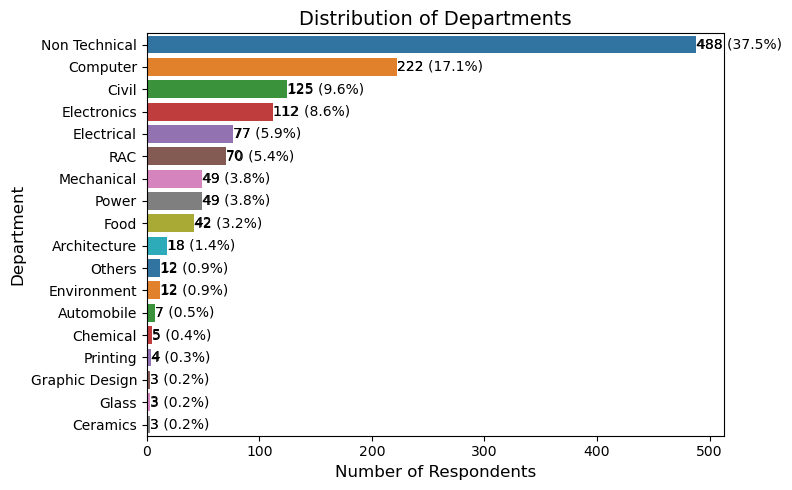

In [20]:
# plt.figure(figsize=(6, 6))
department_counts = df_cleaned['Department'].value_counts()

plt.figure(figsize=(8, 5))
barplot = sns.barplot(
    x=department_counts.values,
    y=department_counts.index,
    palette="tab10"
)

# Add annotations within the bars
for index, value in enumerate(department_counts.values):
    plt.text(value, index, f'{value}', color='black', ha='left', va='center')
    percentage = f'{(value / department_counts.sum() * 100):.1f}%'
    plt.text(value, index, f'{value} ({percentage})', color='black', ha='left', va='center')

plt.title('Distribution of Departments', fontsize=14)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Department', fontsize=12)
plt.tight_layout()
plt.show()
